# 第4章：Implementing a GPT Model from Scratch

**目标：** 从零搭建完整的 GPT 模型架构，并实现简单的文本生成

```
DummyGPT(整体骨架) → LayerNorm → GELU + FeedForward → 残差连接 → TransformerBlock → GPTModel → 文本生成
```

**前置回顾（第2、3章）：**
- 文本经过 BPE 分词 → Token Embedding + Positional Embedding → 输入向量 `(batch, seq_len, emb_dim)`
- Multi-Head Causal Attention 让每个 token 融合上下文信息，输出 shape 不变
- 现在的问题：光有注意力还不够，还需要 **LayerNorm、FeedForward、残差连接** 才能组成完整的 Transformer Block，多个 Block 堆叠才构成 GPT

---

## 4.1 GPT 架构概览 ⭐

GPT 属于 **decoder-only** 架构（只用了原始 Transformer 的解码器部分）。

**GPT-2 (124M) 的核心配置：**

| 参数 | 值 | 含义 |
|------|-----|------|
| `vocab_size` | 50,257 | BPE 词汇表大小 |
| `context_length` | 1,024 | 最大输入 token 数 |
| `emb_dim` | 768 | 嵌入维度 |
| `n_heads` | 12 | 注意力头数 |
| `n_layers` | 12 | Transformer Block 层数 |
| `drop_rate` | 0.1 | Dropout 比率 |
| `qkv_bias` | False | Q/K/V 投影是否带偏置 |

**整体数据流：**
```
Token IDs
   ↓
Token Embedding + Position Embedding
   ↓ Dropout
┌─────────────────────────────┐
│     Transformer Block × 12  │
│  ┌─────────────────────┐    │
│  │ LayerNorm            │    │
│  │ Multi-Head Attention  │    │
│  │ Dropout + Residual   │    │
│  │ LayerNorm            │    │
│  │ FeedForward          │    │
│  │ Dropout + Residual   │    │
│  └─────────────────────┘    │
└─────────────────────────────┘
   ↓
Final LayerNorm
   ↓
Linear (output head) → logits (vocab_size)
```

> 💡 **关键洞察：** GPT 架构虽然有 1.24 亿参数，但代码量并不大——大量元素是**重复堆叠**的。理解一个 Transformer Block，就理解了整个模型。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

print("GPT-2 124M 配置:")
for k, v in GPT_CONFIG_124M.items():
    print(f"  {k}: {v}")

GPT-2 124M 配置:
  vocab_size: 50257
  context_length: 1024
  emb_dim: 768
  n_heads: 12
  n_layers: 12
  drop_rate: 0.1
  qkv_bias: False


### 先搭骨架：DummyGPT

我们先用占位符（Dummy）组件搭出 GPT 的整体骨架，确认数据流正确后，再逐步替换为真实实现。

In [2]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [3]:
# 测试 DummyGPT 的数据流
tokenizer = tiktoken.get_encoding("gpt2")

batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)

print(f"输入 batch shape: {batch.shape}")        # (2, 4)
print(f"输出 logits shape: {logits.shape}")       # (2, 4, 50257)
print(f"\n→ 每个 token 位置输出一个 {GPT_CONFIG_124M['vocab_size']} 维向量")
print(f"→ 代表该位置预测下一个 token 的 logits（未归一化概率）")

输入 batch shape: torch.Size([2, 4])
输出 logits shape: torch.Size([2, 4, 50257])

→ 每个 token 位置输出一个 50257 维向量
→ 代表该位置预测下一个 token 的 logits（未归一化概率）


> 💡 **关键洞察：** DummyGPT 虽然 TransformerBlock 和 LayerNorm 都是空壳，但数据流已经完全正确：
> - 输入 `(batch, seq_len)` 的 token IDs
> - 输出 `(batch, seq_len, vocab_size)` 的 logits
> 
> 接下来我们要做的就是**逐一替换**每个 Dummy 组件为真实实现。

---
## 4.2 Layer Normalization ⭐

**核心问题：** 深度网络训练时，每层输入的分布会不断变化（internal covariate shift），导致训练不稳定。

**LayerNorm 的做法：** 对每个样本的**特征维度**做归一化（均值→0，方差→1），然后加上可学习的缩放（scale）和偏移（shift）。

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

其中 $\mu$ 和 $\sigma^2$ 是沿最后一维计算的均值和方差，$\gamma$（scale）和 $\beta$（shift）是可学习参数。

**为什么是 LayerNorm 而不是 BatchNorm？**
- BatchNorm 沿 batch 维度归一化，在 NLP 中效果差（序列长度不一，batch 小时统计量不稳定）
- LayerNorm 沿特征维度归一化，**每个样本独立**，不依赖 batch 中的其他样本

In [4]:
# 先直观理解归一化的效果
torch.manual_seed(123)
batch_example = torch.randn(2, 5)  # 2个样本, 5个特征

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(f"层输出:\n{out}")

# 沿特征维度计算均值和方差
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print(f"\n均值: {mean.squeeze()}")
print(f"方差: {var.squeeze()}")
print("→ 不同样本的均值和方差差异较大")

层输出:
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

均值: tensor([0.1324, 0.2170], grad_fn=<SqueezeBackward0>)
方差: tensor([0.0231, 0.0398], grad_fn=<SqueezeBackward0>)
→ 不同样本的均值和方差差异较大


In [5]:
# 手动归一化
out_norm = (out - mean) / torch.sqrt(var)
mean_after = out_norm.mean(dim=-1, keepdim=True)
var_after = out_norm.var(dim=-1, keepdim=True)

torch.set_printoptions(sci_mode=False)
print(f"归一化后均值: {mean_after.squeeze()}")
print(f"归一化后方差: {var_after.squeeze()}")
print("→ 均值≈0, 方差≈1")

归一化后均值: tensor([    0.0000,     0.0000], grad_fn=<SqueezeBackward0>)
归一化后方差: tensor([1.0000, 1.0000], grad_fn=<SqueezeBackward0>)
→ 均值≈0, 方差≈1


In [6]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [7]:
# 验证我们的 LayerNorm
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print(f"LayerNorm 后均值: {mean.squeeze()}")
print(f"LayerNorm 后方差: {var.squeeze()}")
print("\n→ 方差不是精确的 1.0，因为加了 eps 防止除零")

LayerNorm 后均值: tensor([     0.0000,     -0.0000], grad_fn=<SqueezeBackward0>)
LayerNorm 后方差: tensor([0.9995, 0.9997], grad_fn=<SqueezeBackward0>)

→ 方差不是精确的 1.0，因为加了 eps 防止除零


### 🤔 思考：LayerNorm 的两个设计细节

| 设计 | 原因 |
|------|------|
| `scale` 和 `shift` 可学习 | 纯归一化可能丢失有用信息，scale/shift 让模型自己决定最佳分布 |
| `unbiased=False`（有偏方差） | GPT-2 原版使用有偏方差（除以 n 而非 n-1），对于 768 维来说差异极小，但为了兼容预训练权重而保持一致 |

> 💡 **GPT 中 LayerNorm 的位置（Pre-LN）：** GPT-2 采用 **Pre-LN** 架构——LayerNorm 放在注意力/FFN **之前**，而非之后。这种设计使训练更稳定，是目前 LLM 的标准做法。

### ✏️ 练习
1. `eps` 设为 `1e-5` 的作用是什么？如果去掉会怎样？
2. 如果把 `unbiased=False` 改成 `True`，结果会有多大差异？试试在 `emb_dim=768` 时对比两种方式的输出。

In [8]:
# 在这里做实验
# 4.2 练习：LayerNorm 中 eps 和 unbiased 参数的作用
import torch
import torch.nn as nn

print("=" * 80)
print("练习 1：eps=1e-5 的作用是什么？如果去掉会怎样？")
print("=" * 80)

# 构造一个极端输入：每个样本的所有特征值完全一样
# 这种情况下，沿最后一维计算方差时，var = 0
x_constant = torch.ones(2, 5) * 3.14

mean = x_constant.mean(dim=-1, keepdim=True)
var = x_constant.var(dim=-1, keepdim=True, unbiased=False)

print("输入 x_constant:")
print(x_constant)
print("\n均值 mean:")
print(mean)
print("\n方差 var:")
print(var)

# 不加 eps 的 LayerNorm
norm_without_eps = (x_constant - mean) / torch.sqrt(var)

# 加 eps 的 LayerNorm
eps = 1e-5
norm_with_eps = (x_constant - mean) / torch.sqrt(var + eps)

print("\n不加 eps 的归一化结果:")
print(norm_without_eps)

print("\n加 eps 的归一化结果:")
print(norm_with_eps)

print("""
结果分析：
1. 当输入向量每个特征值都一样时，方差 var = 0。
2. 如果不加 eps，就会出现 0 / sqrt(0)，结果是 NaN。
3. 加上 eps 后，分母不会等于 0，计算可以稳定进行。
4. 所以 eps=1e-5 的核心作用是：防止除以 0，提升数值稳定性。
""")


print("\n" + "=" * 80)
print("练习 2：unbiased=False 和 unbiased=True 在 emb_dim=768 时差异有多大？")
print("=" * 80)

torch.manual_seed(123)

batch_size = 4
seq_len = 3
emb_dim = 768

x = torch.randn(batch_size, seq_len, emb_dim)

mean = x.mean(dim=-1, keepdim=True)

# GPT / PyTorch LayerNorm 中通常使用 unbiased=False
var_biased = x.var(dim=-1, keepdim=True, unbiased=False)

# 统计学中的无偏方差估计，除以 n-1
var_unbiased = x.var(dim=-1, keepdim=True, unbiased=True)

out_biased = (x - mean) / torch.sqrt(var_biased + eps)
out_unbiased = (x - mean) / torch.sqrt(var_unbiased + eps)

diff = (out_biased - out_unbiased).abs()

print(f"输入 shape: {x.shape}")
print(f"biased 方差均值:   {var_biased.mean().item():.6f}")
print(f"unbiased 方差均值: {var_unbiased.mean().item():.6f}")

print("\n两种归一化输出的差异:")
print(f"最大绝对差异 max diff:  {diff.max().item():.8f}")
print(f"平均绝对差异 mean diff: {diff.mean().item():.8f}")

ratio = var_unbiased.mean() / var_biased.mean()
print(f"\nunbiased 方差 / biased 方差 ≈ {ratio.item():.8f}")
print(f"理论比例 n/(n-1) = {emb_dim / (emb_dim - 1):.8f}")

print("""
结果分析：
1. unbiased=False 表示方差除以 n。
2. unbiased=True 表示方差除以 n-1。
3. 当 emb_dim=768 时，n/(n-1)=768/767≈1.0013，差异非常小。
4. 所以在 GPT 这种高维向量中，两种写法输出差异不大。
5. 但 GPT-2 原始实现使用的是 unbiased=False，因此为了和预训练权重兼容，通常也使用 unbiased=False。
""")

练习 1：eps=1e-5 的作用是什么？如果去掉会怎样？
输入 x_constant:
tensor([[3.1400, 3.1400, 3.1400, 3.1400, 3.1400],
        [3.1400, 3.1400, 3.1400, 3.1400, 3.1400]])

均值 mean:
tensor([[3.1400],
        [3.1400]])

方差 var:
tensor([[0.],
        [0.]])

不加 eps 的归一化结果:
tensor([[nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan]])

加 eps 的归一化结果:
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

结果分析：
1. 当输入向量每个特征值都一样时，方差 var = 0。
2. 如果不加 eps，就会出现 0 / sqrt(0)，结果是 NaN。
3. 加上 eps 后，分母不会等于 0，计算可以稳定进行。
4. 所以 eps=1e-5 的核心作用是：防止除以 0，提升数值稳定性。


练习 2：unbiased=False 和 unbiased=True 在 emb_dim=768 时差异有多大？
输入 shape: torch.Size([4, 3, 768])
biased 方差均值:   1.015074
unbiased 方差均值: 1.016398

两种归一化输出的差异:
最大绝对差异 max diff:  0.00255775
平均绝对差异 mean diff: 0.00051729

unbiased 方差 / biased 方差 ≈ 1.00130379
理论比例 n/(n-1) = 1.00130378

结果分析：
1. unbiased=False 表示方差除以 n。
2. unbiased=True 表示方差除以 n-1。
3. 当 emb_dim=768 时，n/(n-1)=768/767≈1.0013，差异非常小。
4. 所以在 GPT 这种高维向量中，两种写法输出差异不大。
5. 但 GPT-2 原始实现使用的是 unbiased=False，因此为了和预

---
## 4.3 GELU 激活函数与 FeedForward 网络 ⭐

Transformer Block 中，注意力层之后紧跟一个 **前馈网络（FeedForward Network, FFN）**。

FFN 的结构很简单：**两层线性变换夹一个激活函数**。

```
输入 (emb_dim=768)
   ↓ Linear(768, 3072)    ← 扩展 4 倍
   ↓ GELU 激活
   ↓ Linear(3072, 768)    ← 压缩回原维度
输出 (emb_dim=768)
```

### 为什么用 GELU 而不是 ReLU？

| | ReLU | GELU |
|---|---|---|
| 公式 | $\max(0, x)$ | $x \cdot \Phi(x)$ ，$\Phi$ 是标准正态 CDF |
| 特点 | 分段线性，x<0 时梯度为 0 | 平滑，x<0 时梯度不为零 |
| 优势 | 计算快 | 更好的梯度流动，LLM 训练效果更好 |

In [9]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\1\AppData\Local\Temp\ipykernel_39164\504681990.py:13: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_3916

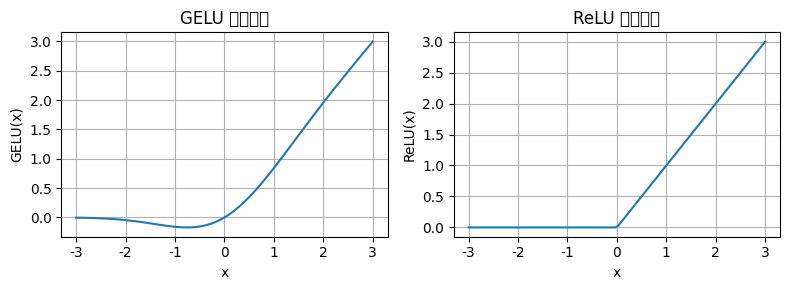

→ GELU 是平滑的，负数区域有微小非零输出
→ ReLU 是分段线性的，负数区域直接截断为 0


In [10]:
# 可视化 GELU vs ReLU
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)

plt.figure(figsize=(8, 3))
for i, (fn, label) in enumerate(zip([gelu, relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, fn(x))
    plt.title(f"{label} 激活函数")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

print("→ GELU 是平滑的，负数区域有微小非零输出")
print("→ ReLU 是分段线性的，负数区域直接截断为 0")

In [11]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [12]:
# 验证 FeedForward 的输入输出形状
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 4, 768)  # (batch, seq_len, emb_dim)
out = ffn(x)

print(f"FFN 输入 shape: {x.shape}")
print(f"FFN 输出 shape: {out.shape}")
print(f"\n→ 输入输出 shape 相同，中间经历 768→3072→768 的维度变化")

# 统计参数量
ffn_params = sum(p.numel() for p in ffn.parameters())
print(f"\nFFN 参数量: {ffn_params:,}")
print(f"  第一层: 768×3072 + 3072(bias) = {768*3072 + 3072:,}")
print(f"  第二层: 3072×768 + 768(bias) = {3072*768 + 768:,}")

FFN 输入 shape: torch.Size([2, 4, 768])
FFN 输出 shape: torch.Size([2, 4, 768])

→ 输入输出 shape 相同，中间经历 768→3072→768 的维度变化

FFN 参数量: 4,722,432
  第一层: 768×3072 + 3072(bias) = 2,362,368
  第二层: 3072×768 + 768(bias) = 2,360,064


> 💡 **关键洞察：为什么中间层要扩大 4 倍？**
>
> FFN 的 768→3072→768 设计被称为 **bottleneck**（瓶颈结构的反面——其实是**expansion**）。
> 扩大 4 倍可以让模型在更高维空间中做非线性变换，然后再压缩回原始维度。
> 这个 4 倍的比例在原始 Transformer 论文中就确定了，后来的 GPT、BERT 等都沿用了。

### ✏️ 练习
1. 计算一下：12 层 Transformer Block 中，所有 FFN 的总参数量是多少？占 GPT-2 124M 总参数的百分比？
2. 把 GELU 替换成 ReLU，对比一下 FFN 的输出有什么不同？

In [13]:
# 在这里做实验
# 4.3 练习：FFN 参数量计算 + GELU 与 ReLU 对比
import torch
import torch.nn as nn

print("=" * 80)
print("练习 1：计算 12 层 Transformer Block 中所有 FFN 的总参数量")
print("=" * 80)

emb_dim = GPT_CONFIG_124M["emb_dim"]
n_layers = GPT_CONFIG_124M["n_layers"]

# 单个 FFN:
# Linear(emb_dim, 4*emb_dim) + GELU + Linear(4*emb_dim, emb_dim)
first_linear_weight = emb_dim * (4 * emb_dim)
first_linear_bias = 4 * emb_dim

second_linear_weight = (4 * emb_dim) * emb_dim
second_linear_bias = emb_dim

single_ffn_params_manual = (
    first_linear_weight
    + first_linear_bias
    + second_linear_weight
    + second_linear_bias
)

all_ffn_params_manual = single_ffn_params_manual * n_layers

print(f"emb_dim = {emb_dim}")
print(f"n_layers = {n_layers}")

print("\n单个 FFN 参数量手动计算:")
print(f"第一层 Linear({emb_dim}, {4 * emb_dim}) 权重: {first_linear_weight:,}")
print(f"第一层 bias: {first_linear_bias:,}")
print(f"第二层 Linear({4 * emb_dim}, {emb_dim}) 权重: {second_linear_weight:,}")
print(f"第二层 bias: {second_linear_bias:,}")
print(f"单个 FFN 总参数量: {single_ffn_params_manual:,}")

print(f"\n12 层 FFN 总参数量: {all_ffn_params_manual:,}")

gpt2_124m = 124_000_000
percent = all_ffn_params_manual / gpt2_124m * 100
print(f"占 GPT-2 124M 参数比例: {percent:.2f}%")

# 用实际 FeedForward 类验证
ffn = FeedForward(GPT_CONFIG_124M)
single_ffn_params_actual = sum(p.numel() for p in ffn.parameters())

print(f"\n用 FeedForward 类实际统计的单个 FFN 参数量: {single_ffn_params_actual:,}")
print(f"手动计算是否一致: {single_ffn_params_actual == single_ffn_params_manual}")

print("""
结果分析：
1. GPT-2 small 的 FFN 是 768 → 3072 → 768。
2. 单个 FFN 参数量约 472 万。
3. 12 层 FFN 参数量约 5667 万。
4. 如果以 GPT-2 small 约 124M 参数计算，FFN 大约占 45.70%。
5. 说明 FFN 是 GPT 参数量中非常重要的一部分，甚至比注意力层还大。
""")


print("\n" + "=" * 80)
print("练习 2：把 GELU 替换成 ReLU，对比 FFN 输出有什么不同")
print("=" * 80)

class FeedForwardReLU(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.ReLU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


# 为了公平比较，让 GELU 版和 ReLU 版使用相同的 Linear 权重
torch.manual_seed(123)
ffn_gelu = FeedForward(GPT_CONFIG_124M)

torch.manual_seed(123)
ffn_relu = FeedForwardReLU(GPT_CONFIG_124M)

x = torch.randn(2, 4, emb_dim)

out_gelu = ffn_gelu(x)
out_relu = ffn_relu(x)

diff = (out_gelu - out_relu).abs()

print(f"输入 shape: {x.shape}")
print(f"GELU FFN 输出 shape: {out_gelu.shape}")
print(f"ReLU FFN 输出 shape: {out_relu.shape}")

print("\n输出统计:")
print(f"GELU 输出均值: {out_gelu.mean().item():.6f}")
print(f"GELU 输出标准差: {out_gelu.std().item():.6f}")
print(f"ReLU 输出均值: {out_relu.mean().item():.6f}")
print(f"ReLU 输出标准差: {out_relu.std().item():.6f}")

print("\n两者输出差异:")
print(f"最大绝对差异: {diff.max().item():.6f}")
print(f"平均绝对差异: {diff.mean().item():.6f}")

# 单独观察 GELU 和 ReLU 对负数的处理
test_values = torch.tensor([-3.0, -1.0, -0.5, 0.0, 0.5, 1.0, 3.0])
gelu = GELU()
relu = nn.ReLU()

print("\nGELU 和 ReLU 对同一组输入的处理:")
for v, g, r in zip(test_values, gelu(test_values), relu(test_values)):
    print(f"x={v.item():>5.1f} | GELU={g.item():>8.4f} | ReLU={r.item():>8.4f}")

print("""
结果分析：
1. GELU 和 ReLU 不改变 FFN 的输出 shape，输出仍然是 (batch, seq_len, emb_dim)。
2. ReLU 会把所有负数直接变成 0。
3. GELU 对负数不是简单截断，而是平滑地压制。
4. 因此即使 Linear 权重完全相同，GELU 版和 ReLU 版 FFN 输出也会不同。
5. GPT、BERT 等 Transformer 模型通常更偏向 GELU，因为它更平滑，训练时梯度变化更自然。
""")

练习 1：计算 12 层 Transformer Block 中所有 FFN 的总参数量
emb_dim = 768
n_layers = 12

单个 FFN 参数量手动计算:
第一层 Linear(768, 3072) 权重: 2,359,296
第一层 bias: 3,072
第二层 Linear(3072, 768) 权重: 2,359,296
第二层 bias: 768
单个 FFN 总参数量: 4,722,432

12 层 FFN 总参数量: 56,669,184
占 GPT-2 124M 参数比例: 45.70%

用 FeedForward 类实际统计的单个 FFN 参数量: 4,722,432
手动计算是否一致: True

结果分析：
1. GPT-2 small 的 FFN 是 768 → 3072 → 768。
2. 单个 FFN 参数量约 472 万。
3. 12 层 FFN 参数量约 5667 万。
4. 如果以 GPT-2 small 约 124M 参数计算，FFN 大约占 45.70%。
5. 说明 FFN 是 GPT 参数量中非常重要的一部分，甚至比注意力层还大。


练习 2：把 GELU 替换成 ReLU，对比 FFN 输出有什么不同
输入 shape: torch.Size([2, 4, 768])
GELU FFN 输出 shape: torch.Size([2, 4, 768])
ReLU FFN 输出 shape: torch.Size([2, 4, 768])

输出统计:
GELU 输出均值: 0.000536
GELU 输出标准差: 0.196467
ReLU 输出均值: 0.000867
ReLU 输出标准差: 0.234245

两者输出差异:
最大绝对差异: 0.298709
平均绝对差异: 0.057735

GELU 和 ReLU 对同一组输入的处理:
x= -3.0 | GELU= -0.0036 | ReLU=  0.0000
x= -1.0 | GELU= -0.1588 | ReLU=  0.0000
x= -0.5 | GELU= -0.1543 | ReLU=  0.0000
x=  0.0 | GELU=  0.0000 | ReLU=  0.0000
x=  0.5 | GELU=  0

---
## 4.4 残差连接（Shortcut / Skip Connection）⭐⭐

**核心问题：** 深度网络中，梯度在反向传播时可能逐层衰减，导致**梯度消失**——前面的层几乎学不到东西。

**残差连接的做法：** 跳过中间层，将输入直接加到输出上。

```
没有残差连接:    x → Layer → y
有残差连接:      x → Layer → y + x    ← 加上原始输入
```

**为什么有效？**
- 梯度可以通过 shortcut 直接传到前面的层（不需要经过所有中间层）
- 即使中间层输出接近 0，信号仍然可以通过

In [14]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()(output, target)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name}: 梯度绝对值均值 = {param.grad.abs().mean().item():.6f}")

In [15]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

print("=" * 60)
print("【无残差连接】")
print("=" * 60)
torch.manual_seed(123)
model_no_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)
print_gradients(model_no_shortcut, sample_input)

print("\n" + "=" * 60)
print("【有残差连接】")
print("=" * 60)
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

【无残差连接】
layers.0.0.weight: 梯度绝对值均值 = 0.000202
layers.1.0.weight: 梯度绝对值均值 = 0.000120
layers.2.0.weight: 梯度绝对值均值 = 0.000715
layers.3.0.weight: 梯度绝对值均值 = 0.001399
layers.4.0.weight: 梯度绝对值均值 = 0.005050

【有残差连接】
layers.0.0.weight: 梯度绝对值均值 = 0.221698
layers.1.0.weight: 梯度绝对值均值 = 0.206941
layers.2.0.weight: 梯度绝对值均值 = 0.328970
layers.3.0.weight: 梯度绝对值均值 = 0.266573
layers.4.0.weight: 梯度绝对值均值 = 1.325854


> 💡 **关键洞察：** 对比两种情况可以看到：
> - **无残差连接：** 越靠前的层（layer.0）梯度越小 → 梯度消失
> - **有残差连接：** 所有层的梯度都在合理范围内 → 训练更均匀
>
> 这就是为什么 Transformer 每个子层（注意力、FFN）都要加残差连接。

### ✏️ 练习
1. 如果把层数从 5 增加到 10 或 20，梯度消失的现象会更严重吗？用代码验证。
2. 残差连接要求 `x.shape == layer_output.shape`，如果两者 shape 不同怎么办？实际中是怎么处理的？

In [16]:
# 在这里做实验
# 4.4 练习：层数增加后梯度消失是否更严重 + shape 不同时如何做残差连接
import torch
import torch.nn as nn

print("=" * 80)
print("练习 1：把层数从 5 增加到 10 或 20，验证梯度消失是否更严重")
print("=" * 80)

class FlexibleDeepNeuralNetwork(nn.Module):
    """
    可以自由指定层数的深层网络。
    为了让残差连接能够直接相加，中间层维度都保持 hidden_dim 不变。
    最后一层输出 1 维，用于计算 MSELoss。
    """
    def __init__(self, input_dim=3, hidden_dim=3, output_dim=1, num_hidden_layers=5, use_shortcut=False):
        super().__init__()
        self.use_shortcut = use_shortcut

        layers = []

        # 第一层：input_dim -> hidden_dim
        layers.append(nn.Sequential(nn.Linear(input_dim, hidden_dim), GELU()))

        # 中间层：hidden_dim -> hidden_dim
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Sequential(nn.Linear(hidden_dim, hidden_dim), GELU()))

        self.hidden_layers = nn.ModuleList(layers)

        # 输出层：hidden_dim -> output_dim
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        for layer in self.hidden_layers:
            layer_output = layer(x)

            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output

        return self.out(x)


def collect_gradient_means(model, x):
    model.zero_grad()

    output = model(x)
    target = torch.zeros_like(output)
    loss = nn.MSELoss()(output, target)
    loss.backward()

    grad_info = []

    for name, param in model.named_parameters():
        if "weight" in name and param.grad is not None:
            grad_info.append((name, param.grad.abs().mean().item()))

    return grad_info


sample_input = torch.tensor([[1.0, 0.0, -1.0]])

for depth in [5, 10, 20]:
    print("\n" + "-" * 80)
    print(f"隐藏层层数: {depth}")
    print("-" * 80)

    torch.manual_seed(123)
    model_no_shortcut = FlexibleDeepNeuralNetwork(
        input_dim=3,
        hidden_dim=3,
        output_dim=1,
        num_hidden_layers=depth,
        use_shortcut=False,
    )

    torch.manual_seed(123)
    model_with_shortcut = FlexibleDeepNeuralNetwork(
        input_dim=3,
        hidden_dim=3,
        output_dim=1,
        num_hidden_layers=depth,
        use_shortcut=True,
    )

    grad_no_shortcut = collect_gradient_means(model_no_shortcut, sample_input)
    grad_with_shortcut = collect_gradient_means(model_with_shortcut, sample_input)

    print("\n无残差连接：")
    for name, grad in grad_no_shortcut[:5]:
        print(f"{name:<35} 梯度绝对值均值 = {grad:.10f}")
    print("...")
    for name, grad in grad_no_shortcut[-3:]:
        print(f"{name:<35} 梯度绝对值均值 = {grad:.10f}")

    print("\n有残差连接：")
    for name, grad in grad_with_shortcut[:5]:
        print(f"{name:<35} 梯度绝对值均值 = {grad:.10f}")
    print("...")
    for name, grad in grad_with_shortcut[-3:]:
        print(f"{name:<35} 梯度绝对值均值 = {grad:.10f}")

    first_grad_no = grad_no_shortcut[0][1]
    first_grad_short = grad_with_shortcut[0][1]

    print(f"\n最前面层梯度对比:")
    print(f"无残差连接第一层梯度: {first_grad_no:.10f}")
    print(f"有残差连接第一层梯度: {first_grad_short:.10f}")

print("""
结果分析：
1. 当网络层数从 5 增加到 10、20 时，无残差连接网络前面层的梯度通常会变得更小。
2. 这说明梯度在从后往前传播时逐层衰减，也就是梯度消失。
3. 加入残差连接后，梯度可以沿着 x + layer_output 中的 x 这条捷径直接往前传。
4. 所以前面层更容易获得有效梯度，训练深层网络更稳定。
""")


print("\n" + "=" * 80)
print("练习 2：如果 x.shape 和 layer_output.shape 不同，残差连接怎么办？")
print("=" * 80)

class ResidualWithProjection(nn.Module):
    """
    演示 shape 不一致时，使用 Linear 投影把 shortcut 映射到相同维度。
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            GELU()
        )

        # 如果 in_dim != out_dim，就用投影层调整 shortcut 的维度
        if in_dim != out_dim:
            self.shortcut_projection = nn.Linear(in_dim, out_dim)
        else:
            self.shortcut_projection = nn.Identity()

    def forward(self, x):
        layer_output = self.layer(x)
        shortcut = self.shortcut_projection(x)
        return layer_output + shortcut


x = torch.randn(2, 3)

# 输入是 3 维，输出是 6 维，不能直接 x + layer_output
block = ResidualWithProjection(in_dim=3, out_dim=6)
y = block(x)

print(f"输入 x shape: {x.shape}")
print(f"输出 y shape: {y.shape}")

print("""
结果分析：
1. 残差连接要求两个张量 shape 一样，才能逐元素相加。
2. 如果 shape 不一样，不能直接 x + layer_output。
3. 常见解决方法是增加一个 projection 投影层，例如 Linear(in_dim, out_dim)。
4. 在 CNN 里也常用 1×1 卷积调整通道数。
5. 在 GPT 的 TransformerBlock 中，Attention 和 FFN 的输入输出都是 emb_dim，所以通常不需要额外投影。
""")

练习 1：把层数从 5 增加到 10 或 20，验证梯度消失是否更严重

--------------------------------------------------------------------------------
隐藏层层数: 5
--------------------------------------------------------------------------------

无残差连接：
hidden_layers.0.0.weight            梯度绝对值均值 = 0.0004105674
hidden_layers.1.0.weight            梯度绝对值均值 = 0.0003584870
hidden_layers.2.0.weight            梯度绝对值均值 = 0.0015532270
hidden_layers.3.0.weight            梯度绝对值均值 = 0.0029427821
hidden_layers.4.0.weight            梯度绝对值均值 = 0.0051318025
...
hidden_layers.3.0.weight            梯度绝对值均值 = 0.0029427821
hidden_layers.4.0.weight            梯度绝对值均值 = 0.0051318025
out.weight                          梯度绝对值均值 = 0.0888778865

有残差连接：
hidden_layers.0.0.weight            梯度绝对值均值 = 0.2192146182
hidden_layers.1.0.weight            梯度绝对值均值 = 0.1791837811
hidden_layers.2.0.weight            梯度绝对值均值 = 0.2525893152
hidden_layers.3.0.weight            梯度绝对值均值 = 0.3305433989
hidden_layers.4.0.weight            梯度绝对值均值 = 0.1612928510
...
h

---
## 4.5 Transformer Block ⭐⭐

现在我们把所有组件组合在一起，构建 **Transformer Block**——GPT 的基本构建单元。

**一个 Transformer Block 的结构：**
```
输入 x
  │
  ├──────────────────────────┐ (残差连接)
  ↓                          │
LayerNorm                    │
  ↓                          │
Multi-Head Causal Attention  │
  ↓                          │
Dropout                      │
  ↓                          │
  + ←─────────────────────────┘ (加上原始输入)
  │
  ├──────────────────────────┐ (残差连接)
  ↓                          │
LayerNorm                    │
  ↓                          │
FeedForward                  │
  ↓                          │
Dropout                      │
  ↓                          │
  + ←─────────────────────────┘ (加上原始输入)
  │
输出
```

注意：这里我们需要用到第 3 章实现的 `MultiHeadAttention`，直接在这里重新定义。

In [17]:
# 第3章实现的 MultiHeadAttention（高效版本）
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        context_vecs = self.out_proj(context_vecs)

        return context_vecs

In [18]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 子层 1: Multi-Head Attention + 残差连接
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # 子层 2: FeedForward + 残差连接
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [19]:
# 验证 TransformerBlock
torch.manual_seed(123)
x = torch.rand(2, 4, 768)  # (batch=2, seq_len=4, emb_dim=768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print(f"输入 shape: {x.shape}")
print(f"输出 shape: {output.shape}")
print(f"\n→ 输入输出 shape 完全相同！这保证了 Block 可以堆叠")

# TransformerBlock 参数量
block_params = sum(p.numel() for p in block.parameters())
print(f"\n单个 TransformerBlock 参数量: {block_params:,}")
print(f"12 个 Block 总参数量: {block_params * 12:,}")

输入 shape: torch.Size([2, 4, 768])
输出 shape: torch.Size([2, 4, 768])

→ 输入输出 shape 完全相同！这保证了 Block 可以堆叠

单个 TransformerBlock 参数量: 7,085,568
12 个 Block 总参数量: 85,026,816


### 🤔 思考：Pre-LN vs Post-LN

| | Post-LN（原始Transformer） | Pre-LN（GPT-2）|
|---|---|---|
| LN 位置 | 注意力/FFN **之后** | 注意力/FFN **之前** |
| 残差连接 | `x + LN(SubLayer(x))` | `x + SubLayer(LN(x))` |
| 训练稳定性 | 需要 warmup | 更稳定，不一定需要 warmup |
| 实际使用 | 原始 Transformer, BERT | GPT-2, GPT-3, LLaMA 等 |

> 💡 我们实现的是 **Pre-LN** 版本（先 Norm 再做子层运算），这是 GPT-2 及后续大模型的标准做法。

### ✏️ 练习
1. 验证：如果把 `norm1` 移到 `self.att(x)` 之后（Post-LN），输出 shape 是否还正确？
2. 单个 TransformerBlock 中，MHA 和 FFN 各占多少参数？哪个更多？

In [20]:
# 在这里做实验
# 4.5 练习：Post-LN 输出 shape 验证 + MHA 与 FFN 参数量对比
import torch
import torch.nn as nn

print("=" * 80)
print("练习 1：把 norm1 移到 self.att(x) 之后，验证输出 shape 是否正确")
print("=" * 80)

class TransformerBlockPostLN(nn.Module):
    """
    用来对比的 Post-LN TransformerBlock。
    
    原 notebook 里的 GPT-2 风格是 Pre-LN:
        x = x + Attention(LayerNorm(x))
        x = x + FFN(LayerNorm(x))

    这里改成 Post-LN:
        x = LayerNorm(x + Attention(x))
        x = LayerNorm(x + FFN(x))
    """
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 子层 1：Attention + 残差 + LayerNorm
        shortcut = x
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        x = self.norm1(x)

        # 子层 2：FFN + 残差 + LayerNorm
        shortcut = x
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        x = self.norm2(x)

        return x


torch.manual_seed(123)
x = torch.rand(2, 4, GPT_CONFIG_124M["emb_dim"])

pre_ln_block = TransformerBlock(GPT_CONFIG_124M)
post_ln_block = TransformerBlockPostLN(GPT_CONFIG_124M)

pre_ln_out = pre_ln_block(x)
post_ln_out = post_ln_block(x)

print(f"输入 shape: {x.shape}")
print(f"Pre-LN TransformerBlock 输出 shape:  {pre_ln_out.shape}")
print(f"Post-LN TransformerBlock 输出 shape: {post_ln_out.shape}")

print(f"\nPost-LN 输出 shape 是否和输入一致: {post_ln_out.shape == x.shape}")

diff = (pre_ln_out - post_ln_out).abs().mean().item()
print(f"Pre-LN 和 Post-LN 输出平均绝对差异: {diff:.6f}")

print("""
结果分析：
1. 把 norm1 移到 Attention 后面，输出 shape 依然正确。
2. 因为 Attention 和 FFN 都被设计成输入输出维度相同：emb_dim → emb_dim。
3. 所以无论 LayerNorm 放在子层之前还是之后，都不会改变 shape。
4. 但是输出数值会不同，因为计算顺序变了。
5. GPT-2 使用 Pre-LN，主要原因是深层 Transformer 训练时更稳定。
""")


print("\n" + "=" * 80)
print("练习 2：单个 TransformerBlock 中，MHA 和 FFN 各占多少参数？")
print("=" * 80)

block = TransformerBlock(GPT_CONFIG_124M)

mha_params = sum(p.numel() for p in block.att.parameters())
ffn_params = sum(p.numel() for p in block.ff.parameters())
norm_params = sum(p.numel() for p in block.norm1.parameters()) + sum(p.numel() for p in block.norm2.parameters())
total_block_params = sum(p.numel() for p in block.parameters())

print(f"MHA 参数量: {mha_params:,}")
print(f"FFN 参数量: {ffn_params:,}")
print(f"两个 LayerNorm 参数量: {norm_params:,}")
print(f"单个 TransformerBlock 总参数量: {total_block_params:,}")

print("\n占单个 Block 的比例:")
print(f"MHA 占比: {mha_params / total_block_params * 100:.2f}%")
print(f"FFN 占比: {ffn_params / total_block_params * 100:.2f}%")
print(f"LayerNorm 占比: {norm_params / total_block_params * 100:.4f}%")

if ffn_params > mha_params:
    print("\n结论：FFN 参数量更多。")
else:
    print("\n结论：MHA 参数量更多。")

print("""
参数量分析：
1. MHA 主要包括 W_query、W_key、W_value 和 out_proj。
2. 在 emb_dim=768 时，MHA 大约是 236 万参数。
3. FFN 是 768→3072→768，大约是 472 万参数。
4. 所以单个 Block 里，FFN 参数量大约是 MHA 的 2 倍。
5. LayerNorm 只有 scale 和 shift，参数量非常少，几乎可以忽略。
""")

练习 1：把 norm1 移到 self.att(x) 之后，验证输出 shape 是否正确
输入 shape: torch.Size([2, 4, 768])
Pre-LN TransformerBlock 输出 shape:  torch.Size([2, 4, 768])
Post-LN TransformerBlock 输出 shape: torch.Size([2, 4, 768])

Post-LN 输出 shape 是否和输入一致: True
Pre-LN 和 Post-LN 输出平均绝对差异: 0.798817

结果分析：
1. 把 norm1 移到 Attention 后面，输出 shape 依然正确。
2. 因为 Attention 和 FFN 都被设计成输入输出维度相同：emb_dim → emb_dim。
3. 所以无论 LayerNorm 放在子层之前还是之后，都不会改变 shape。
4. 但是输出数值会不同，因为计算顺序变了。
5. GPT-2 使用 Pre-LN，主要原因是深层 Transformer 训练时更稳定。


练习 2：单个 TransformerBlock 中，MHA 和 FFN 各占多少参数？
MHA 参数量: 2,360,064
FFN 参数量: 4,722,432
两个 LayerNorm 参数量: 3,072
单个 TransformerBlock 总参数量: 7,085,568

占单个 Block 的比例:
MHA 占比: 33.31%
FFN 占比: 66.65%
LayerNorm 占比: 0.0434%

结论：FFN 参数量更多。

参数量分析：
1. MHA 主要包括 W_query、W_key、W_value 和 out_proj。
2. 在 emb_dim=768 时，MHA 大约是 236 万参数。
3. FFN 是 768→3072→768，大约是 472 万参数。
4. 所以单个 Block 里，FFN 参数量大约是 MHA 的 2 倍。
5. LayerNorm 只有 scale 和 shift，参数量非常少，几乎可以忽略。



---
## 4.6 组装完整 GPTModel ⭐⭐⭐

现在把所有组件组装到一起！用真实的 `TransformerBlock` 和 `LayerNorm` 替换之前的 Dummy 版本。

In [21]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [22]:
# 实例化真正的 GPT 模型
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print(f"输入 batch shape: {batch.shape}")
print(f"输出 logits shape: {out.shape}")
print(f"\n→ 与 DummyGPT 的输出 shape 完全一致")
print(f"→ 但现在每个 Transformer Block 都是真实的计算")

输入 batch shape: torch.Size([2, 4])
输出 logits shape: torch.Size([2, 4, 50257])

→ 与 DummyGPT 的输出 shape 完全一致
→ 但现在每个 Transformer Block 都是真实的计算


In [23]:
# 参数量分析
total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params:,}")

print(f"\n→ 为什么是 ~163M 而不是 124M？")
print(f"\nToken Embedding 层 shape: {model.tok_emb.weight.shape}")
print(f"Output 层 shape:          {model.out_head.weight.shape}")
print(f"→ 两者 shape 一样！都是 (50257, 768)")

# GPT-2 原版使用 weight tying（共享这两个矩阵）
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"\n去掉 output 层后（weight tying）: {total_params_gpt2:,}")
print(f"→ 这就是 124M 参数的来源！")

总参数量: 163,009,536

→ 为什么是 ~163M 而不是 124M？

Token Embedding 层 shape: torch.Size([50257, 768])
Output 层 shape:          torch.Size([50257, 768])
→ 两者 shape 一样！都是 (50257, 768)

去掉 output 层后（weight tying）: 124,412,160
→ 这就是 124M 参数的来源！


In [24]:
# 模型大小（显存占用）
total_size_bytes = total_params * 4  # float32: 4 bytes per parameter
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"模型大小 (float32): {total_size_mb:.2f} MB")
print(f"模型大小 (float16): {total_size_mb / 2:.2f} MB")

模型大小 (float32): 621.83 MB
模型大小 (float16): 310.92 MB


### 🤔 思考：Weight Tying（权重共享）

GPT-2 原版将 Token Embedding 和 Output Head 共享权重：`self.out_head.weight = self.tok_emb.weight`

**直觉理解：**
- Token Embedding 的工作：token ID → 语义向量
- Output Head 的工作：语义向量 → 预测哪个 token（本质是反向映射）
- 两者互为「逆操作」，共享权重是合理的

**我们没有实现 weight tying 的原因：**
- 不共享训练效果可能更好
- 第 5 章加载 GPT-2 预训练权重时会重新讨论这个话题

**GPT-2 各版本参数对比：**

| 版本 | emb_dim | n_layers | n_heads | 参数量 |
|------|---------|----------|---------|--------|
| GPT2-small | 768 | 12 | 12 | 124M |
| GPT2-medium | 1024 | 24 | 16 | 345M |
| GPT2-large | 1280 | 36 | 20 | 762M |
| GPT2-XL | 1600 | 48 | 25 | 1542M |

### ✏️ 练习
1. 修改配置为 GPT2-medium（emb_dim=1024, n_layers=24, n_heads=16），计算参数量，验证是否接近 345M。
2. GPT-2 的 `qkv_bias=False`，但加载预训练权重时会设为 `True`。为什么？（提示：OpenAI 原始实现用了 bias）

In [25]:
# 在这里做实验
# 4.6 练习：GPT-2 medium 参数量计算 + qkv_bias 解释
import torch
import torch.nn as nn
import copy

print("=" * 80)
print("练习 1：修改配置为 GPT-2 medium，计算参数量")
print("=" * 80)

GPT_CONFIG_MEDIUM = copy.deepcopy(GPT_CONFIG_124M)
GPT_CONFIG_MEDIUM.update({
    "emb_dim": 1024,
    "n_layers": 24,
    "n_heads": 16,
    # 这里先保持 qkv_bias=False，和当前 notebook 的 GPTModel 实现一致
    "qkv_bias": False,
})

print("GPT-2 medium 配置:")
for k, v in GPT_CONFIG_MEDIUM.items():
    print(f"{k}: {v}")


def calculate_gpt_params(cfg, with_output_head=True, qkv_bias=False):
    """
    不真正实例化大模型，而是手动计算参数量。
    这样更省内存，避免 GPT-2 medium 实例化占用太多显存/内存。
    """
    vocab_size = cfg["vocab_size"]
    context_length = cfg["context_length"]
    emb_dim = cfg["emb_dim"]
    n_layers = cfg["n_layers"]

    # token embedding
    tok_emb_params = vocab_size * emb_dim

    # position embedding
    pos_emb_params = context_length * emb_dim

    # 每个 TransformerBlock 的参数量
    # MHA:
    # Wq, Wk, Wv: emb_dim -> emb_dim
    # out_proj: emb_dim -> emb_dim，默认有 bias
    qkv_weight_params = 3 * emb_dim * emb_dim
    qkv_bias_params = 3 * emb_dim if qkv_bias else 0

    out_proj_weight_params = emb_dim * emb_dim
    out_proj_bias_params = emb_dim

    mha_params = (
        qkv_weight_params
        + qkv_bias_params
        + out_proj_weight_params
        + out_proj_bias_params
    )

    # FFN:
    # Linear(emb_dim, 4*emb_dim) + bias
    # Linear(4*emb_dim, emb_dim) + bias
    ffn_params = (
        emb_dim * (4 * emb_dim)
        + (4 * emb_dim)
        + (4 * emb_dim) * emb_dim
        + emb_dim
    )

    # LayerNorm:
    # 每个 LayerNorm 有 scale 和 shift，各 emb_dim
    # 每个 block 有两个 LayerNorm
    ln_params_per_block = 2 * (2 * emb_dim)

    block_params = mha_params + ffn_params + ln_params_per_block

    all_blocks_params = block_params * n_layers

    # final LayerNorm
    final_norm_params = 2 * emb_dim

    # output head
    output_head_params = vocab_size * emb_dim if with_output_head else 0

    total = (
        tok_emb_params
        + pos_emb_params
        + all_blocks_params
        + final_norm_params
        + output_head_params
    )

    detail = {
        "tok_emb_params": tok_emb_params,
        "pos_emb_params": pos_emb_params,
        "mha_params_per_block": mha_params,
        "ffn_params_per_block": ffn_params,
        "ln_params_per_block": ln_params_per_block,
        "block_params": block_params,
        "all_blocks_params": all_blocks_params,
        "final_norm_params": final_norm_params,
        "output_head_params": output_head_params,
        "total": total,
    }

    return total, detail


# 当前 notebook 风格：不共享 output_head，所以会比官方 GPT-2 medium 大
medium_total_no_tying, medium_detail_no_tying = calculate_gpt_params(
    GPT_CONFIG_MEDIUM,
    with_output_head=True,
    qkv_bias=False,
)

# GPT-2 官方参数量通常按 weight tying 统计，即不额外计算 output_head
medium_total_with_tying, medium_detail_with_tying = calculate_gpt_params(
    GPT_CONFIG_MEDIUM,
    with_output_head=False,
    qkv_bias=False,
)

print("\n不使用 weight tying，也就是保留独立 output_head:")
print(f"参数量: {medium_total_no_tying:,}")
print(f"约等于: {medium_total_no_tying / 1e6:.2f}M")

print("\n使用 weight tying，也就是 output_head 和 tok_emb 共享:")
print(f"参数量: {medium_total_with_tying:,}")
print(f"约等于: {medium_total_with_tying / 1e6:.2f}M")

print("\n参数量分解，按 weight tying 口径:")
for k, v in medium_detail_with_tying.items():
    print(f"{k:<25}: {v:,}")

print("""
结果分析：
1. 当前 notebook 的 GPTModel 没有做 weight tying，所以会额外多一个 output_head。
2. GPT-2 官方参数量通常按照 token embedding 和 output head 共享权重来统计。
3. 因此计算 GPT-2 medium 时，使用 weight tying 后参数量约为 354M。
4. 官方常说 GPT-2 medium 是 345M，二者接近但不完全一样。
5. 差异来自实现细节，例如 bias、词表大小、位置编码、统计口径等。
""")


print("\n" + "=" * 80)
print("练习 2：为什么加载 OpenAI GPT-2 预训练权重时 qkv_bias 要设为 True？")
print("=" * 80)

# 对比 qkv_bias=False 和 qkv_bias=True 对参数量的影响
medium_total_qkv_bias_true, _ = calculate_gpt_params(
    GPT_CONFIG_MEDIUM,
    with_output_head=False,
    qkv_bias=True,
)

extra_params = medium_total_qkv_bias_true - medium_total_with_tying

print(f"qkv_bias=False 参数量: {medium_total_with_tying:,}")
print(f"qkv_bias=True  参数量: {medium_total_qkv_bias_true:,}")
print(f"多出来的 QKV bias 参数量: {extra_params:,}")

expected_extra = 3 * GPT_CONFIG_MEDIUM["emb_dim"] * GPT_CONFIG_MEDIUM["n_layers"]
print(f"理论多出来的参数量 = 3 * emb_dim * n_layers = {expected_extra:,}")

print("""
结果分析：
1. 当前 notebook 里 qkv_bias=False，是为了简化实现。
2. 但是 OpenAI 原始 GPT-2 的 Q/K/V 投影层使用了 bias。
3. 如果加载官方 GPT-2 预训练权重，模型结构必须和官方权重形状一致。
4. 如果你的模型 qkv_bias=False，而官方权重里有 bias，就会出现参数缺失或 shape 对不上的问题。
5. 所以加载 GPT-2 官方预训练权重时，通常要把 qkv_bias=True。
""")

练习 1：修改配置为 GPT-2 medium，计算参数量
GPT-2 medium 配置:
vocab_size: 50257
context_length: 1024
emb_dim: 1024
n_heads: 16
n_layers: 24
drop_rate: 0.1
qkv_bias: False

不使用 weight tying，也就是保留独立 output_head:
参数量: 406,212,608
约等于: 406.21M

使用 weight tying，也就是 output_head 和 tok_emb 共享:
参数量: 354,749,440
约等于: 354.75M

参数量分解，按 weight tying 口径:
tok_emb_params           : 51,463,168
pos_emb_params           : 1,048,576
mha_params_per_block     : 4,195,328
ffn_params_per_block     : 8,393,728
ln_params_per_block      : 4,096
block_params             : 12,593,152
all_blocks_params        : 302,235,648
final_norm_params        : 2,048
output_head_params       : 0
total                    : 354,749,440

结果分析：
1. 当前 notebook 的 GPTModel 没有做 weight tying，所以会额外多一个 output_head。
2. GPT-2 官方参数量通常按照 token embedding 和 output head 共享权重来统计。
3. 因此计算 GPT-2 medium 时，使用 weight tying 后参数量约为 354M。
4. 官方常说 GPT-2 medium 是 345M，二者接近但不完全一样。
5. 差异来自实现细节，例如 bias、词表大小、位置编码、统计口径等。


练习 2：为什么加载 OpenAI GPT-2 预训练权重时 qkv_bias 要设为 True？
q

---
## 4.7 文本生成（Greedy Decoding）⭐⭐

模型搭好了，虽然还没训练，但我们可以先实现**文本生成**的逻辑。

**Greedy Decoding（贪心解码）：**
- 每一步选择概率最高的 token 作为输出
- 简单快速，但容易重复、不够多样

```
输入: "Hello, I am"
   ↓ 模型预测下一个 token 的概率分布
选择概率最高的 token (argmax)
   ↓ 将新 token 追加到输入
"Hello, I am [new_token]"
   ↓ 重复...
"Hello, I am [new_token] [new_token2] ..."
```

In [26]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """简单的贪心解码文本生成"""
    for _ in range(max_new_tokens):
        # 截断到上下文长度
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # 只取最后一个位置的预测
        logits = logits[:, -1, :]  # (batch, vocab_size)

        # 贪心: 选概率最高的 token
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 追加到序列
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [27]:
# 用未训练的模型生成文本
model.eval()

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # (1, n_tokens)

print(f"输入文本: '{start_context}'")
print(f"Token IDs: {encoded}")
print(f"输入 shape: {encoded_tensor.shape}")

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)

decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(f"\n生成结果: '{decoded_text}'")
print(f"\n→ 输出是随机的，因为模型还没有训练！")
print(f"→ 第 5 章会训练这个模型，届时会生成有意义的文本")

输入文本: 'Hello, I am'
Token IDs: [15496, 11, 314, 716]
输入 shape: torch.Size([1, 4])

生成结果: 'Hello, I am Featureiman Byeswickattribute argue'

→ 输出是随机的，因为模型还没有训练！
→ 第 5 章会训练这个模型，届时会生成有意义的文本


### 🤔 思考：为什么只用最后一个位置的 logits？

模型输出 `(batch, seq_len, vocab_size)`，但我们只取 `logits[:, -1, :]`（最后一个位置），为什么？

因为 GPT 是**因果模型**：
- 位置 0 的输出只看到了 token 0 → 预测 token 1
- 位置 1 的输出看到了 token 0, 1 → 预测 token 2
- ...
- 位置 n-1 的输出看到了 token 0..n-1 → 预测 token n

所以**最后一个位置**的输出融合了所有已知信息，是预测下一个 token 的最佳位置。

### ✏️ 练习
1. 增加 `max_new_tokens` 到 20 或 50，观察生成结果有什么特点？
2. 如果输入文本长度超过 `context_length`（1024 tokens），`generate_text_simple` 是如何处理的？这种处理方式有什么缺点？
3. （进阶）修改 `generate_text_simple`，把 `argmax` 换成按概率采样（`torch.multinomial`），观察生成结果的变化。

In [28]:
# 在这里做实验
# 4.7 练习：增加生成长度 + 分析 context 截断 + 改成概率采样
import torch
import torch.nn.functional as F

print("=" * 80)
print("练习 1：增加 max_new_tokens 到 20 或 50，观察生成结果")
print("=" * 80)

model.eval()

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)

print(f"输入文本: {start_context}")
print(f"输入 token ids: {encoded}")
print(f"输入 shape: {encoded_tensor.shape}")

for max_new_tokens in [20, 50]:
    torch.manual_seed(123)

    out = generate_text_simple(
        model=model,
        idx=encoded_tensor.clone(),
        max_new_tokens=max_new_tokens,
        context_size=GPT_CONFIG_124M["context_length"],
    )

    decoded_text = tokenizer.decode(out.squeeze(0).tolist())

    print("\n" + "-" * 80)
    print(f"max_new_tokens = {max_new_tokens}")
    print("-" * 80)
    print(decoded_text)

print("""
结果分析：
1. max_new_tokens 越大，生成文本越长。
2. 但是当前模型还没有训练，所以生成内容通常是随机、不连贯、甚至重复的。
3. Greedy decoding 每一步都取概率最大的 token，因此容易陷入重复模式。
4. 只有模型经过预训练后，生成结果才会具有语言规律。
""")


print("\n" + "=" * 80)
print("练习 2：输入超过 context_length 时，generate_text_simple 如何处理？")
print("=" * 80)

def generate_text_simple_with_debug(model, idx, max_new_tokens, context_size):
    """
    在原始 generate_text_simple 基础上加入打印信息，
    用于观察 idx[:, -context_size:] 的截断行为。
    """
    for step in range(max_new_tokens):
        original_len = idx.shape[1]

        # 关键代码：只保留最后 context_size 个 token
        idx_cond = idx[:, -context_size:]

        truncated_len = idx_cond.shape[1]

        print(f"step {step + 1}: 原始长度={original_len}, 输入模型的长度={truncated_len}")

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# 为了演示方便，不用 1024，改用一个很小的 context_size=8
# 这样更容易看到截断效果
long_text = "Hello, I am learning how GPT models generate text step by step."
long_ids = tokenizer.encode(long_text)
long_tensor = torch.tensor(long_ids).unsqueeze(0)

print(f"原始文本: {long_text}")
print(f"原始 token 数量: {long_tensor.shape[1]}")
print(f"这里为了演示，设置 context_size=8")

_ = generate_text_simple_with_debug(
    model=model,
    idx=long_tensor,
    max_new_tokens=5,
    context_size=8,
)

print("""
结果分析：
1. generate_text_simple 里面有一行：idx_cond = idx[:, -context_size:]。
2. 这表示如果输入长度超过 context_size，只保留最后 context_size 个 token。
3. 例如 context_size=1024 时，模型最多只能看到最近的 1024 个 token。
4. 缺点是：更早的上下文会被丢掉。
5. 如果长文前面有重要信息，例如人物设定、主题、约束条件，模型后面可能会忘记。
""")


print("\n" + "=" * 80)
print("练习 3：把 argmax 改成 torch.multinomial 概率采样")
print("=" * 80)

def generate_text_sampling(model, idx, max_new_tokens, context_size, temperature=1.0, top_k=None):
    """
    使用概率采样生成文本，而不是每次都 argmax。

    参数解释：
    - temperature 越低，分布越尖锐，越接近 greedy。
    - temperature 越高，分布越平滑，随机性越强。
    - top_k 表示只从概率最高的 k 个 token 中采样。
    """
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        # temperature 缩放
        logits = logits / temperature

        # top-k 截断：只保留概率最高的 k 个候选 token
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_top_logit = top_logits[:, -1].unsqueeze(-1)
            logits = torch.where(
                logits < min_top_logit,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )

        probas = torch.softmax(logits, dim=-1)

        # 按概率分布采样，而不是取最大概率
        idx_next = torch.multinomial(probas, num_samples=1)

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


print("Greedy decoding 结果:")
torch.manual_seed(123)
greedy_out = generate_text_simple(
    model=model,
    idx=encoded_tensor.clone(),
    max_new_tokens=30,
    context_size=GPT_CONFIG_124M["context_length"],
)
print(tokenizer.decode(greedy_out.squeeze(0).tolist()))

print("\n概率采样结果 1：temperature=1.0, top_k=None")
torch.manual_seed(123)
sample_out_1 = generate_text_sampling(
    model=model,
    idx=encoded_tensor.clone(),
    max_new_tokens=30,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=1.0,
    top_k=None,
)
print(tokenizer.decode(sample_out_1.squeeze(0).tolist()))

print("\n概率采样结果 2：temperature=1.5, top_k=50")
torch.manual_seed(123)
sample_out_2 = generate_text_sampling(
    model=model,
    idx=encoded_tensor.clone(),
    max_new_tokens=30,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=1.5,
    top_k=50,
)
print(tokenizer.decode(sample_out_2.squeeze(0).tolist()))

print("""
结果分析：
1. Greedy decoding 每一步都选择概率最大的 token，结果稳定，但容易重复。
2. multinomial 采样会根据概率分布随机抽取 token，因此每次结果可能不同。
3. temperature 控制随机性：
   - temperature 小：更保守，更接近 argmax；
   - temperature 大：更随机，生成结果更多样。
4. top_k 限制只从概率最高的 k 个 token 里采样，可以避免采到过于离谱的 token。
5. 当前模型没有训练，所以无论 greedy 还是 sampling，文本都不会真正通顺。
6. 但从机制上看，sampling 比 greedy 更有多样性，是大模型生成中常见的解码策略。
""")

练习 1：增加 max_new_tokens 到 20 或 50，观察生成结果
输入文本: Hello, I am
输入 token ids: [15496, 11, 314, 716]
输入 shape: torch.Size([1, 4])

--------------------------------------------------------------------------------
max_new_tokens = 20
--------------------------------------------------------------------------------
Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous bore ITVEGIN ministriesysics Kle functional recountrictionchanging

--------------------------------------------------------------------------------
max_new_tokens = 50
--------------------------------------------------------------------------------
Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous bore ITVEGIN ministriesysics Kle functional recountrictionchangingVirgin embarrassedgl Truthfoundation challenges essence specifically Absent� 421 lov Castro Fewug wins Hus Golemllyyll Fisher sim trimュPrintOracle Five purpose FO treacherous

结果分析：
1. max_new_tokens 越大，生成文本越长。
2. 

---
## 4.8 完整流程回顾

让我们用一张图回顾整个第4章的内容：

In [29]:
print("═" * 70)
print("  第4章完整流程：从零搭建 GPT 模型")
print("═" * 70)
print()
print("  1. DummyGPT ─────────── 搭建骨架，确认数据流")
print("     ↓")
print("  2. LayerNorm ────────── 归一化：均值→0, 方差→1")
print("     ↓")
print("  3. GELU + FeedForward ─ 非线性变换：768→3072→768")
print("     ↓")
print("  4. 残差连接 ──────────── 防止梯度消失")
print("     ↓")
print("  5. TransformerBlock ─── LN + MHA + 残差 + LN + FFN + 残差")
print("     ↓")
print("  6. GPTModel ─────────── 12 个 Block 堆叠 → 完整 GPT-2 (124M)")
print("     ↓")
print("  7. 文本生成 ──────────── Greedy Decoding (尚未训练)")
print("     ↓")
print("  8. 第5章：预训练 ────── 让模型真正学会语言！ 🚀")
print()
print("═" * 70)
print(f"\n  模型配置: GPT-2 124M")
print(f"  总参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"  模型大小: {sum(p.numel() for p in model.parameters()) * 4 / 1024 / 1024:.1f} MB (float32)")
print(f"  Transformer Blocks: {GPT_CONFIG_124M['n_layers']}")
print(f"  注意力头数: {GPT_CONFIG_124M['n_heads']}")
print(f"  嵌入维度: {GPT_CONFIG_124M['emb_dim']}")
print(f"  上下文长度: {GPT_CONFIG_124M['context_length']}")

══════════════════════════════════════════════════════════════════════
  第4章完整流程：从零搭建 GPT 模型
══════════════════════════════════════════════════════════════════════

  1. DummyGPT ─────────── 搭建骨架，确认数据流
     ↓
  2. LayerNorm ────────── 归一化：均值→0, 方差→1
     ↓
  3. GELU + FeedForward ─ 非线性变换：768→3072→768
     ↓
  4. 残差连接 ──────────── 防止梯度消失
     ↓
  5. TransformerBlock ─── LN + MHA + 残差 + LN + FFN + 残差
     ↓
  6. GPTModel ─────────── 12 个 Block 堆叠 → 完整 GPT-2 (124M)
     ↓
  7. 文本生成 ──────────── Greedy Decoding (尚未训练)
     ↓
  8. 第5章：预训练 ────── 让模型真正学会语言！ 🚀

══════════════════════════════════════════════════════════════════════

  模型配置: GPT-2 124M
  总参数量: 163,009,536
  模型大小: 621.8 MB (float32)
  Transformer Blocks: 12
  注意力头数: 12
  嵌入维度: 768
  上下文长度: 1024


---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] GPT 的整体架构是怎样的？数据是如何流经各个组件的？
- [ ] LayerNorm 的作用是什么？Pre-LN 和 Post-LN 有什么区别？
- [ ] GELU 激活函数与 ReLU 的区别？为什么 LLM 更倾向于用 GELU？
- [ ] FeedForward 为什么要先扩大 4 倍再缩回来？
- [ ] 残差连接如何缓解梯度消失问题？
- [ ] TransformerBlock 内部的两个子层分别是什么？各自的作用？
- [ ] GPT-2 124M 的参数量为什么实际是 ~163M？什么是 weight tying？
- [ ] Greedy Decoding 是如何工作的？为什么只取最后一个位置的 logits？
- [ ] 能否独立写出 GPTModel 的完整代码（不看笔记）？

全部能回答 → 进入第 5 章：在无标签数据上预训练 GPT！🚀